In [2]:
# Reload modules automatically
%load_ext autoreload
%autoreload 2

In [1]:

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

In [3]:
import cma
import numpy as np
from numbers import Real
import torch
from PIL import Image
import random
import requests
from io import BytesIO
import time
from matplotlib import cm
import matplotlib.pyplot as plt
from tqdm import tqdm
from os import path
import os
from IPython.display import display, clear_output


# Utils imports
from utils.rasterize import *
from utils.load import get_segment_imgs, get_primitive_imgs
from utils.clipemb import CLIP_emb_from_IMG, CLIP_emb_from_TEXT
from utils.cma import clip_sol


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

WIDTH = 300
HEIGHT = 300

CONTENT_DIR = './data'
RESULTS_DIR = path.join(CONTENT_DIR, 'results')
PRIMITIVES_DIR = path.join(CONTENT_DIR, 'primitives')
SEGMENT_DIR = path.join(CONTENT_DIR, 'segment_img')

SEGMENT_IMGS = get_segment_imgs(SEGMENT_DIR, (WIDTH, HEIGHT))
PRIMITIVES_IMGS = get_primitive_imgs(PRIMITIVES_DIR, (WIDTH, HEIGHT))

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.50, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [4]:
prompt_text = 'the statue of liberty'
prompt_text = 'a person wearing a yellow coat is holding a small red umbrella with his left hand over his head'
prompt_text = 'a person under an umbrella'
prompt_embedding = CLIP_emb_from_TEXT(prompt_text)
#prompt_embedding = CLIP_emb_from_IMG(SEGMENT_IMGS[prompt_text]['original'])

# primitives_selected_names = list(SEGMENT_IMGS[prompt_text].keys())
# primitives_selected_names.remove('original') # This is the original image aka the prompt

# primitives_selected = [SEGMENT_IMGS[prompt_text][name] for name in primitives_selected_names]

primitives_selected = [PRIMITIVES_IMGS['person'], PRIMITIVES_IMGS['umbrella']]

# Initial solution
predictN = 5
N = len(primitives_selected)

x0 = np.ones((N, 5))
# (x, y) positions
x0[:, 0] = 1 / N * np.arange(N) + (1 / N) / 2
x0[:, 0] = 0
x0[:, 1] = 0.25
# s scale
x0[:, 2] = 0.55
x0[1, 2] = 0.1
# r rotation
x0[:, 3] = 0.6
# l layer
x0[:, 4] = x0[:, 0]


# SPECIFIC
if False:
    x0[1, 0] = 0.45
    x0[1, 1] = 0.10
    
    x0[2, 0] = 0.50

    x0[0, 0] = 0.65
    x0[0, 1] = 0.25

    x0[1, 2] = 0.17
    x0[0, 2] = 0.12
x0 = np.array([[0, 0, 0.8, 0, 1], [0, 0.3, 0.8, 0, 0]])
im0 = rasterize_shapes(primitives_selected, x0, (WIDTH, HEIGHT))

#prompt_embedding = CLIP_emb_from_IMG(im0)


cuda


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [5]:
def loss(solution):
    solution = np.clip(solution.reshape(-1, predictN), 0.01, 1)
    img = rasterize_shapes_2(primitives_selected, solution, (WIDTH, HEIGHT))
    img = Image.alpha_composite(
        #Image.new("RGBA", img.size, (54, 108, 176, 255)),  # White background
        Image.new("RGBA", img.size, (255, 255, 255, 255)),  # White background
        img
    ).convert("RGB")

    rasterized_imgs = torch.tensor(np.array(img)).permute(2, 0, 1).to(DEVICE)
    rasterized_emb = CLIP_emb_from_IMG(rasterized_imgs) 

    return -torch.nn.functional.cosine_similarity(rasterized_emb, prompt_embedding, dim=1).item()

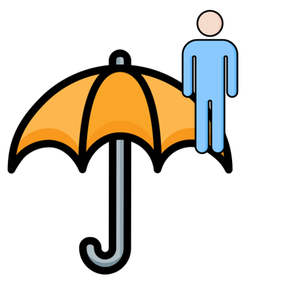

Loss for x1: 0.3252476453781128


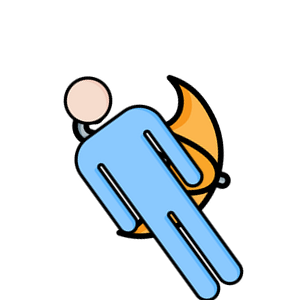

Loss for x2: 0.23162443935871124


In [6]:
x0 = np.ones((N, 5))
x1 = np.array([[0.9, 0.05, 0.5, 0, 1], [0, 0.7, 0.8, 0, 0]])
display(rasterize_shapes_2(primitives_selected, x1, (WIDTH, HEIGHT)))
print(f'Loss for x1: {loss(x1)*-1}') #0.2822265028953552

x2 = np.array([[0.5, 0.05, 0.9, 0.1, 1], [0.5, 0.6, 0.6, 0.7, 0]])
display(rasterize_shapes_2(primitives_selected, x2, (WIDTH, HEIGHT)))
x0 = x2
print(f'Loss for x2: {loss(x2)*-1}')

In [7]:
sigma = 0.1
maxiter = 200
popsize = 512
max_val = 0.5

x0 = x0 - max_val
es = cma.CMAEvolutionStrategy(x0.flatten(), sigma, {
        "maxiter": maxiter,
        "popsize": popsize,
        "bounds": [-max_val, max_val],
    })

(256_w,512)-aCMA-ES (mu_w=131.7,w_1=2%) in dimension 10 (seed=1083782, Tue Mar 25 19:07:24 2025)


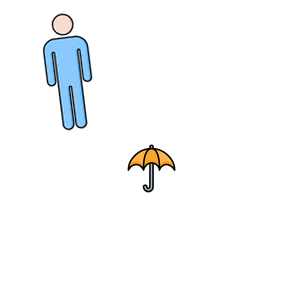

tensor(0.3794, device='cuda:0')


In [9]:
report_interval = 1
i = 0
while not es.stop():
    a = time.time()
    solutions = es.ask()

    rasterized_imgs = []

    b = time.time()
    for it, solution in enumerate(solutions):
      # Reshape (one for each primitive)
      solution = solution.reshape(-1, predictN)

      solution = clip_sol(solution, max_val)
      

      img = rasterize_shapes_2(primitives_selected, solution, (WIDTH, HEIGHT))
      rasterized_imgs.append(Image.alpha_composite(
                                #Image.new("RGBA", img.size, (54, 108, 176, 255)),  # Blue background
                                Image.new("RGBA", img.size, (255, 255, 255, 255)),  # White background
                                img
                            ).convert("RGB"))

    rasterized_imgs = np.stack(rasterized_imgs, axis=0) # (population_size, 300, 300, 4)
    rasterized_imgs = torch.tensor(rasterized_imgs).permute(0, 3, 1, 2).to(DEVICE)
    c = time.time()
    rasterized_emb = CLIP_emb_from_IMG(rasterized_imgs) # (population_size, 512)

    losses = torch.nn.functional.cosine_similarity(rasterized_emb, prompt_embedding, dim=1)

    t = time.time()
    print(f"ALL: {b-a}")
    print(f"SOL: {c-b}")
    print(f"EMB: {t-c}")
    print(f'best loss = {losses.max()}')
    print(f'avg loss = {np.average(losses.cpu())}')
    if i % report_interval == 0:
      print(f'loss migliore = {losses.max()}')
      best = solutions[losses.argmax()]
      img = rasterized_imgs[losses.argmax()].cpu().numpy()
      img = np.transpose(img, (1,2,0))
      img_pil = Image.fromarray(img.astype('uint8'), 'RGB')
      #img_pil.save(path.join(RESULTS_DIR, f'img{i}.png'))
      clear_output(wait=True)  # Clear previous output
      display(img_pil)         # Display the new image

    print(losses.max())
    # Minus because we want to maximize the similarity
    es.tell(solutions, [-l.item() for l in losses])
    i += 1
  
